In [1]:
import numpy as np

from rlbench.action_modes.action_mode import MoveArmThenGripper
from rlbench.action_modes.arm_action_modes import JointVelocity
from rlbench.action_modes.gripper_action_modes import Discrete
from rlbench.environment import Environment
from rlbench.observation_config import ObservationConfig, CameraConfig
from rlbench.task_environment import TaskEnvironment


from rlbench.backend.observation import Observation
from rlbench.demo import Demo

from pyrep.const import RenderMode
from pyrep.objects import Object

import numpy as np
import torch
import torch.nn.functional as F

from policy import Policy, Agent, CamType

import matplotlib.pyplot as plt

from utils import set_seed

##Tasks  
from rlbench.tasks.reach_target_no_obs_central import ReachTargetNoObsCentral as Central
from rlbench.tasks.reach_target_no_obs_side_r import ReachTargetNoObsSideR as SideR
from rlbench.tasks.reach_target_no_obs_side_l import ReachTargetNoObsSideL as SideL

set_seed(42)


In [2]:

cam_type = CamType.WRIST

live_demos = True
DATASET = '' if live_demos else 'PATH/TO/YOUR/DATASET'

obs_config = ObservationConfig()
obs_config.set_all(True) ## important to get the data from the joints etc
cam_config = CameraConfig(rgb=True, depth=False, mask=False,
                              render_mode=RenderMode.OPENGL,
                    image_size=(64, 64))
nocam_config = CameraConfig(rgb=False, depth=False, mask=False,
                          render_mode=RenderMode.OPENGL)

obs_config.right_shoulder_camera = cam_config
obs_config.left_shoulder_camera = cam_config
obs_config.overhead_camera = nocam_config
obs_config.front_camera = nocam_config

## active camera: wrist camera
obs_config.wrist_camera = cam_config


action_mode = MoveArmThenGripper(
    arm_action_mode=JointVelocity(), gripper_action_mode=Discrete())

env = Environment(
    action_mode, DATASET, obs_config, False)
env.launch()





In [3]:
def get_task_name(task) -> str:
  if task == Central:
    return "Central"
  elif task == SideL:
    return "Side Left"
  elif task == SideR:
    return "Side Right"
  else:
    raise ValueError("[request_demos_and_train_for_task] Task not found!")

## 
def request_demos_and_train_for_task(current_task, agent: Agent, num_demos: int,  save_model = False, **training_params) -> TaskEnvironment:
  task_name = get_task_name(current_task) 
  
  ## load this task into env
  task_env = env.get_task(current_task) # removes all other loaded tasks
  ## num_demos defined in the 
  demos: list[Demo] = task_env.get_demos(num_demos, live_demos=live_demos)
  agent.ingest(demos, **training_params)
  if save_model:
    model_name = f"task-{task_name}-{num_demos}-demo-{cam_type}"
    model_path = f"./models/{model_name}.pth"
    agent.save_model(model_path)
  
  return task_env

def run_task(
  env: Environment,
  task,
  cam_type: CamType,
  demo_count: int,
  max_eplen: int = 100,
  **training_params
) -> list[float]:
  print(f"Training for {demo_count} demos for task: {get_task_name(task)}")
  ## new agent trained each time
  agent = Agent(env.action_shape[0], cam_type)
  
  ## request demos and train
  task_env = request_demos_and_train_for_task(
    task,
    agent,
    demo_count,
    save_model=True,
    **training_params
  )
  
  ## evaluate
  obs: Observation
  _, obs = task_env.reset()
  agent.policy.to("cpu") # move to cpu
  distances = []
  
  for _ in range(max_eplen):
    action = agent.act(obs).squeeze()
    obs, reward, done = task_env.step(action)

    gripper = Object.get_object("Panda_gripper")
    target = Object.get_object("target")
    distance = np.linalg.norm(gripper.get_position() - target.get_position())
    distances.append(distance)
    if done:
      break
    
  return distances

- For each task, the episode length (number of frames captuures) is ~50, therefore will give the system 80 steps
- second set of graphs allow it to go up to 300

In [4]:
max_eplen = 100 ## tried 80 first, see if there is a difference

from pprint import pprint
repeats = 10
tasks = [Central, SideR, SideL]
demo_counts = [1, 2, 5, 10]

In [ ]:

results = [{
  task: {
    demo_count: {"min_dist": None, "final_dist": None}
    for demo_count in demo_counts
    
  }
  for task in tasks
} for _ in range(repeats)]

for i in range(repeats):
  for task in tasks:
    for demo_count in demo_counts:
      distances = run_task(env, task, cam_type, demo_count, max_eplen)
      
      results[i][task][demo_count]["min_dist"] = min(distances)
      results[i][task][demo_count]["final_dist"] = distances[-1]
      


Training for 1 demos for task: Central
Training Params: 
	epochs = 200, 
	minibatch_size = 32, 
	lr = 0.001, 
	model_path = None, 
	cuda



 45%|████▌     | 90/200 [00:00<00:00, 176.02it/s]


KeyboardInterrupt: 

In [ ]:
pprint(results, indent = 2)

## HyperParam Search
as the number of demo frames I have are low, I am going to try higher learning rates, see how that affects learning

Doing thisn because the side[l/r] performs very badly for one demonstration, so the network must not be optimal

In [5]:
from itertools import product
params = {
  "epochs": [100, 200],
  "minibatch_size": [16, 32],
  "lr": [0.01, 0.005, 0.0025]
}

max_eplen = 100
repeats = 1

demo_count = 1
## do for 1 demo see the differces
results = {}
for epoch, mb_size,lr  in product(params["epochs"], params["minibatch_size"], params["lr"]):
  final_dists_avg = {task: 0 for task in tasks}
  min_dists_avg = {task: 0 for task in tasks}
  for task in tasks:
    for i in range(repeats):
      distances = run_task(env, task, cam_type, demo_count, max_eplen, epochs=epoch, minibatch_size=mb_size, lr=lr)
      final_dists_avg[task] += distances[-1]    
      min_dists_avg[task] += min(distances)
      
    results[(epoch, mb_size, lr, task)] = {
        "final_dists": final_dists_avg[task]  / repeats,
        "min_dists": min_dists_avg[task] / repeats
    }
    
print("Done")

Training for 1 demos for task: Central
Training Params: 
	epochs = 100, 
	minibatch_size = 16, 
	lr = 0.01, 
	model_path = None, 
	cuda



100%|██████████| 100/100 [00:00<00:00, 134.24it/s]


Done Training Policy on 1 Demos
Saved Model under './models/task-Central-1-demo-wrist.pth'
Training for 1 demos for task: Side Right
Training Params: 
	epochs = 100, 
	minibatch_size = 16, 
	lr = 0.01, 
	model_path = None, 
	cuda



100%|██████████| 100/100 [00:00<00:00, 176.53it/s]


Done Training Policy on 1 Demos
Saved Model under './models/task-Side Right-1-demo-wrist.pth'
Training for 1 demos for task: Side Left
Training Params: 
	epochs = 100, 
	minibatch_size = 16, 
	lr = 0.01, 
	model_path = None, 
	cuda



...

Done Training Policy on 1 Demos
Saved Model under './models/task-Central-1-demo-wrist.pth'
Training for 1 demos for task: Side Right
Training Params: 
	epochs = 200, 
	minibatch_size = 32, 
	lr = 0.0025, 
	model_path = None, 
	cuda



100%|██████████| 200/200 [00:00<00:00, 271.43it/s]


Done Training Policy on 1 Demos
Saved Model under './models/task-Side Right-1-demo-wrist.pth'
Training for 1 demos for task: Side Left
Training Params: 
	epochs = 200, 
	minibatch_size = 32, 
	lr = 0.0025, 
	model_path = None, 
	cuda



100%|██████████| 200/200 [00:00<00:00, 263.43it/s]


Done Training Policy on 1 Demos
Saved Model under './models/task-Side Left-1-demo-wrist.pth'
Done


In [34]:
import pandas as pd
data = []
for (e, mb, lr, task), metrics in results.items():
  data.append({
        'epoch': e,
        'minibatch_size': mb,
        'learning_rate': lr,
        'taskname': get_task_name(task),
        'final_dist': metrics['final_dists'],
        'min_dist': metrics['min_dists']
    })

# Create a DataFrame
df = pd.DataFrame(data)
# print(df)
df.to_csv("results.csv", index=False)

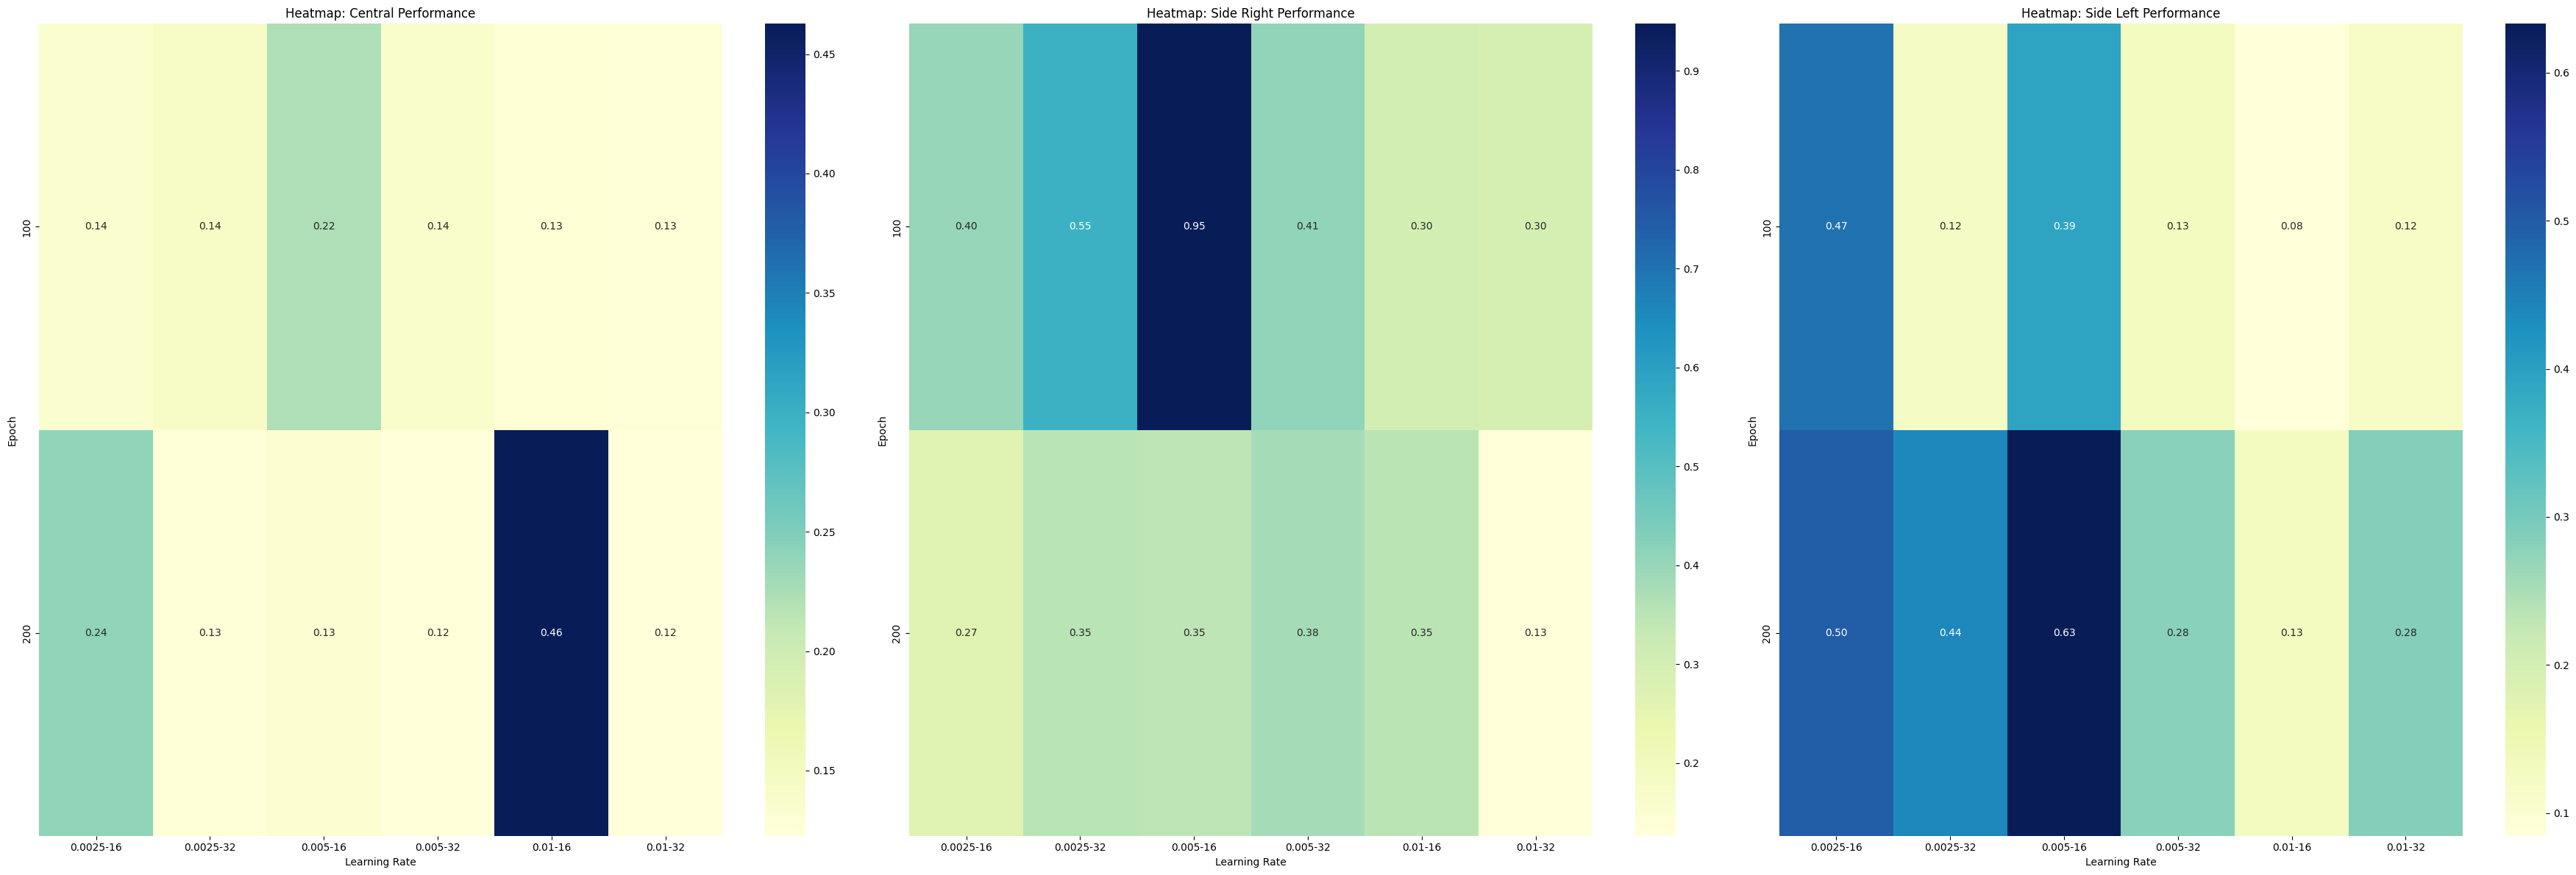

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of task names


# Create a figure with subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(36, 12))

# Loop through each task to create a pivot table and plot
for i, task in enumerate(tasks):
    task = get_task_name(task)  # Get the task name for the current task
    # Filter the data for the current task
    task_data = df[df['taskname'] == task]

    # Pivot the data for the current task
    heatmap_data = task_data.pivot_table(index='epoch', columns=['learning_rate', "minibatch_size"], values='final_dist', aggfunc='mean')

    # Check if there are any NaN values, and handle them (fill with 0 or interpolate)
    heatmap_data = heatmap_data.fillna(0)  # or interpolate()

    # Plot the heatmap for the current task
    sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.2f', ax=axes[i])

    # Set the title for each subplot
    axes[i].set_title(f'Heatmap: {task} Performance')
    axes[i].set_xlabel('Learning Rate')
    axes[i].set_ylabel('Epoch')

# Adjust layout
plt.tight_layout()
plt.show()

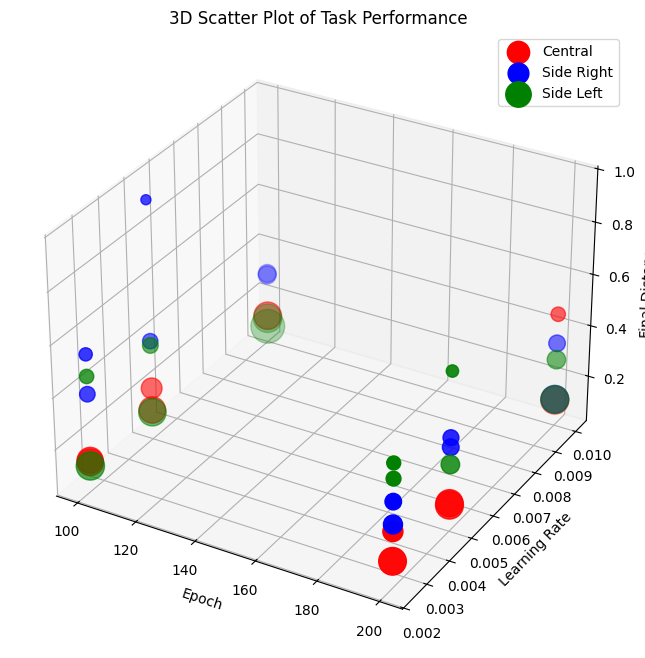

In [54]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Combine data for all tasks (assuming your data is in 'df')
df_combined = df[df['taskname'].isin(list(map(get_task_name, tasks)))]
# Create a 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Define a color palette for the tasks
task_palette = {Central: 'r', SideL: 'g', SideR: 'b'}

# Plot the data
for task in tasks:
    task_name = get_task_name(task)
    task_data = df_combined[df_combined['taskname'] == task_name]
    
    # Scatter plot for each task (epoch, learning_rate, final_dist)
    ax.scatter(
        task_data['epoch'], 
        task_data['learning_rate'], 
        task_data['final_dist'], 
        c=task_palette[task], 
        label=task_name, 
        s=50 * (1 / task_data["final_dist"]) # Size of the scatter points
    )

# Labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_zlabel('Final Distance')
ax.set_title('3D Scatter Plot of Task Performance')

# Legend
ax.legend()

# Show plot
plt.show()

In [38]:
import plotly.express as px

# Parallel coordinates plot
fig = px.parallel_coordinates(
    df, 
    color='final_dist', 
    labels={
        'epoch': 'Epoch', 
        'minibatch_size': 'Minibatch Size', 
        'learning_rate': 'Learning Rate', 
        'final_dist': 'Final Distance'
    },
    dimensions=['epoch', 'minibatch_size', 'learning_rate', 'final_dist']
)

fig.show()

In [ ]:
import plotly.graph_objects as go
import plotly.subplots as sp

colours =  plt.cm.viridis(np.linspace(0, 1, len(tasks)))
task_cm =  {task: colour for task, colour in zip(tasks, colours)}

colours = ['blue', 'red', 'green', 'purple', 'orange', 'cyan', 'magenta']

data = results


fig = go.Figure()

# Plot each task in the same 3D plot with different colors
for task in tasks:
  print(f"Plotting task: {get_task_name(task)}")
  epochs = [k[0] for k in data.keys() if k[3] == task]
  minibatches = [k[1] for k in data.keys() if k[3] == task]
  lrs = [k[2] for k in data.keys() if k[3] == task]
  final_dists = [data[k]['final_dists'] for k in data.keys() if k[3] == task]
  min_dists = [data[k]['min_dists'] for k in data.keys() if k[3] == task]

  # Add scatter plot for this task to the combined figure
  
  task_name = get_task_name(task)
  fig.add_trace(go.Scatter3d(
    x=epochs,
    y=minibatches,
    z=lrs,
    mode='markers',
    name=task_name,
    marker=dict(
        size=8,
        color=final_dists,  # Use final_dists for color intensity
        colorscale='Viridis',  # Color scale
        showscale=True,  # Display color scale
        colorbar=dict(title="Final Dist")
    ),
    text=[f"Task: {task_name}<br>Epochs: {ep}<br>Minibatch: {mb}<br>LR: {lr}<br>Final Dist: {fd:.4f}<br>Min Dist: {md:.4f}"
          for ep, mb, lr, fd, md in zip(epochs, minibatches, lrs, final_dists, min_dists)],
    hoverinfo='text'
  ))

# Set up labels and title
fig.update_layout(
    title="3D Hyperparameter Visualization for Multiple Tasks",
    scene=dict(
        xaxis_title='Epochs',
        yaxis_title='Minibatch Size',
        zaxis_title='Learning Rate',
        zaxis_type='log'  # Log scale for learning rate (optional)
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

# Show interactive plot
fig.show()

Plotting task: Central
Plotting task: Side Right
Plotting task: Side Left


## Plot the 10 Runs
- 10 individual runs to see the differences
- Final averaged distance to goal

> //TODO: Might rerun with more leeway with the completion

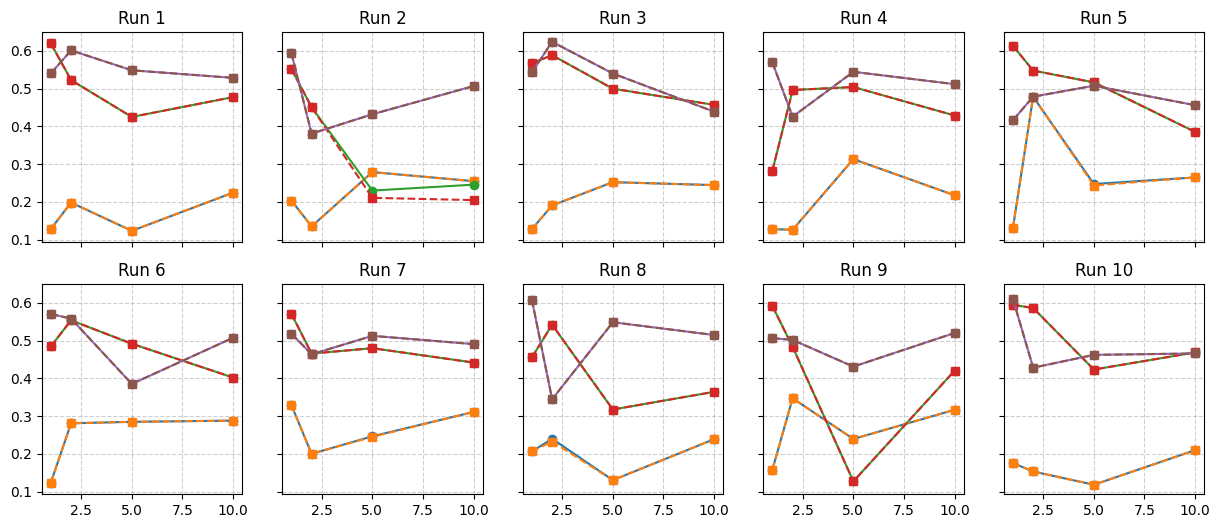

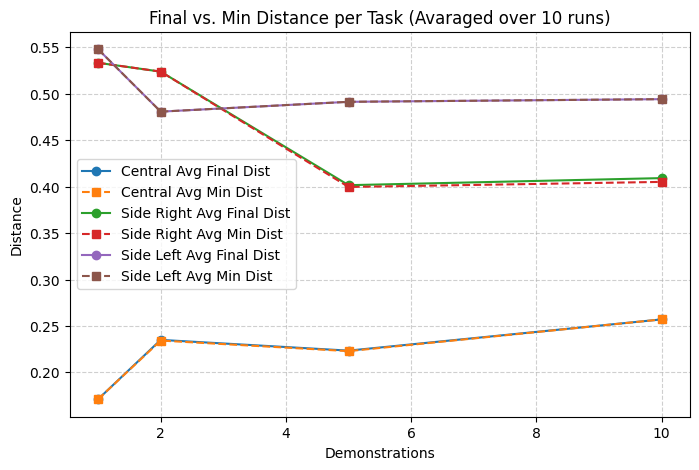

In [ ]:
## Original, episode length allowed = 80

# Extracting tasks and distances
tasks = list(results[0].keys())

final_dists = {task: [results[0][task][demo]['final_dist'] for demo in demo_counts] for task in tasks}
min_dists = {task: [results[0][task][demo]['min_dist'] for demo in demo_counts] for task in tasks}

# Initialize figure
fig, axes = plt.subplots(2, (repeats + 1) // 2, figsize=(15, 6), sharex=True, sharey=True)
axes = axes.flatten()

# Collect data for averaging
final_dists_avg = {task: np.zeros(len(demo_counts)) for task in tasks}
min_dists_avg = {task: np.zeros(len(demo_counts)) for task in tasks}

# Plot individual runs
for run_idx in range(repeats):
  for task in tasks:
    task_name = get_task_name(task)
    final_dists = [results[run_idx][task][demo]['final_dist'] for demo in demo_counts]
    min_dists = [results[run_idx][task][demo]['min_dist'] for demo in demo_counts]
    
    final_dists_avg[task] += np.array(final_dists)
    min_dists_avg[task] += np.array(min_dists)
    
    axes[run_idx].plot(demo_counts, final_dists, marker='o', linestyle='-', label=f'{task_name} Final Dist')
    axes[run_idx].plot(demo_counts, min_dists, marker='s', linestyle='--', label=f'{task_name} Min Dist')
  
  axes[run_idx].set_title(f'Run {run_idx+1}')
  axes[run_idx].grid(True, linestyle='--', alpha=0.6)
    

# Average the distances
total_runs = 10
for task in tasks:
  final_dists_avg[task] /= total_runs
  min_dists_avg[task] /= total_runs

# Create an averaged graph
plt.figure(figsize=(8, 5))
for task in tasks:
  task_name = get_task_name(task)
  plt.plot(demo_counts, final_dists_avg[task], marker='o', linestyle='-', label=f'{task_name} Avg Final Dist')
  plt.plot(demo_counts, min_dists_avg[task], marker='s', linestyle='--', label=f'{task_name} Avg Min Dist')
    
    
plt.xlabel('Demonstrations')
plt.ylabel('Distance')
plt.title(f'Final vs. Min Distance per Task (Avaraged over {repeats} runs)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

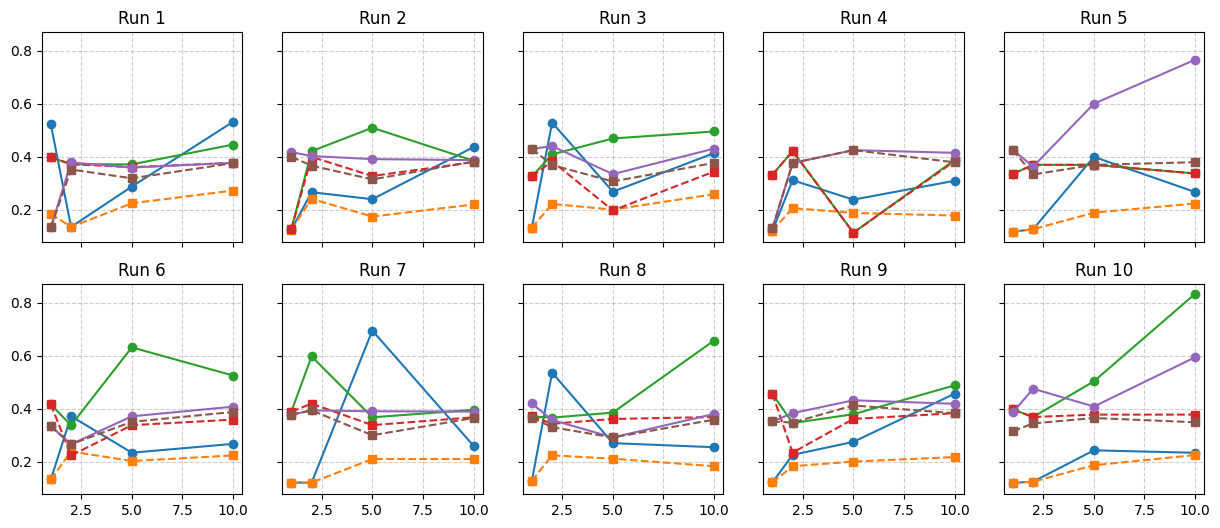

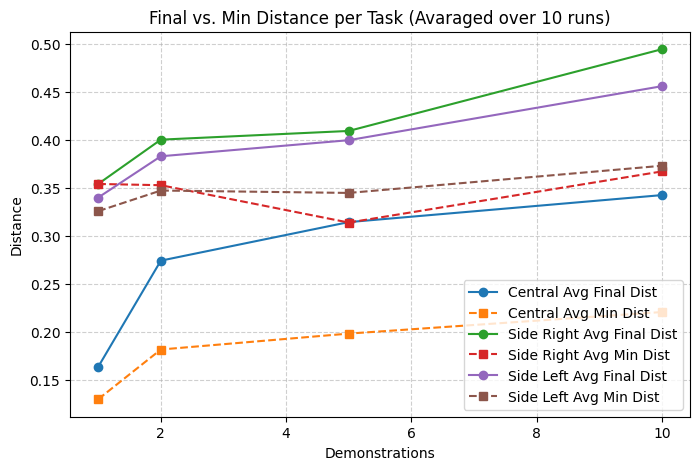

In [ ]:
## More Leeway, max episode length is 300

# Extracting tasks and distances
tasks = list(results[0].keys())

final_dists = {task: [results[0][task][demo]['final_dist'] for demo in demo_counts] for task in tasks}
min_dists = {task: [results[0][task][demo]['min_dist'] for demo in demo_counts] for task in tasks}

# Initialize figure
fig, axes = plt.subplots(2, (repeats + 1) // 2, figsize=(15, 6), sharex=True, sharey=True)
axes = axes.flatten()

# Collect data for averaging
final_dists_avg = {task: np.zeros(len(demo_counts)) for task in tasks}
min_dists_avg = {task: np.zeros(len(demo_counts)) for task in tasks}

# Plot individual runs
for run_idx in range(repeats):
  for task in tasks:
    task_name = get_task_name(task)
    final_dists = [results[run_idx][task][demo]['final_dist'] for demo in demo_counts]
    min_dists = [results[run_idx][task][demo]['min_dist'] for demo in demo_counts]
    
    final_dists_avg[task] += np.array(final_dists)
    min_dists_avg[task] += np.array(min_dists)
    
    axes[run_idx].plot(demo_counts, final_dists, marker='o', linestyle='-', label=f'{task_name} Final Dist')
    axes[run_idx].plot(demo_counts, min_dists, marker='s', linestyle='--', label=f'{task_name} Min Dist')
  
  axes[run_idx].set_title(f'Run {run_idx+1}')
  axes[run_idx].grid(True, linestyle='--', alpha=0.6)
    

# Average the distances
total_runs = 10
for task in tasks:
  final_dists_avg[task] /= total_runs
  min_dists_avg[task] /= total_runs

# Create an averaged graph
plt.figure(figsize=(8, 5))
for task in tasks:
  task_name = get_task_name(task)
  plt.plot(demo_counts, final_dists_avg[task], marker='o', linestyle='-', label=f'{task_name} Avg Final Dist')
  plt.plot(demo_counts, min_dists_avg[task], marker='s', linestyle='--', label=f'{task_name} Avg Min Dist')
    
    
plt.xlabel('Demonstrations')
plt.ylabel('Distance')
plt.title(f'Final vs. Min Distance per Task (Avaraged over {repeats} runs)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
env.shutdown()